## DFT test results analysis (large_random_20260104_194839)

This notebook loads all `*.json` in:

- `QHFlow/src/md/test_script/dft_test_results_large_random_20260104_194839`

and computes:

- Sorting by **minimum interatomic distance** (computed from `atom_configuration.positions`)  
  (If you meant a *specific pair* distance, tell me which atoms; we can swap the distance definition.)
- **Energy error** stats (from `differences.*.energy`)
- **H-only force MAE** stats (computed from `rks.forces` vs `scflow.forces` on H atoms)
- Grouped stats by **distance bins** and **atom_count bins**


✓ 폰트 파일 발견: DIN_1451_LT_Pro_Engschrift.otf
✓ 폰트 파일 발견: DIN_2014_Bold_Italic.otf
✓ 폰트 파일 발견: DIN_2014_Demi.otf
✓ 폰트 파일 발견: DIN_2014_Extra_Bold_Italic.otf
✓ 폰트 파일 발견: DIN_2014_Extra_Light_Italic.otf
✓ 폰트 파일 발견: DIN_2014_Narrow_Demi.otf
✓ 폰트 파일 발견: DIN_2014_Narrow_Light.otf
✓ 폰트 파일 발견: DIN_2014.otf
✓ 폰트 파일 발견: DIN_Condensed_Light.otf
✓ 폰트 파일 발견: DIN_Condensed_VF.otf
✓ 폰트 파일 발견: DIN_Condensed.otf

총 11개의 DIN 폰트 파일을 찾았습니다.

✓ 등록 성공: DIN 1451 LT Pro Engschrift (DIN_1451_LT_Pro_Engschrift.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Bold_Italic.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Demi.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Extra_Bold_Italic.otf)
✓ 등록 성공: DIN 2014 (DIN_2014_Extra_Light_Italic.otf)
✓ 등록 성공: DIN 2014 Narrow (DIN_2014_Narrow_Demi.otf)
✓ 등록 성공: DIN 2014 Narrow (DIN_2014_Narrow_Light.otf)
✓ 등록 성공: DIN 2014 (DIN_2014.otf)
✓ 등록 성공: DIN Condensed (DIN_Condensed_Light.otf)
✓ 등록 성공: DIN Condensed VF (DIN_Condensed_VF.otf)
✓ 등록 성공: DIN Condensed (DIN_Condensed.otf)

총 11개의 폰트가 등록되었습니다.

matplotlib에서 인식된 DIN 

/tmp/ipykernel_1569426/379566279.py:173: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DIN 2014.
  plt.tight_layout()
/root/miniforge3/envs/pyscf-gpu/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DIN 2014.
  fig.canvas.print_figure(bytes_io, **kw)


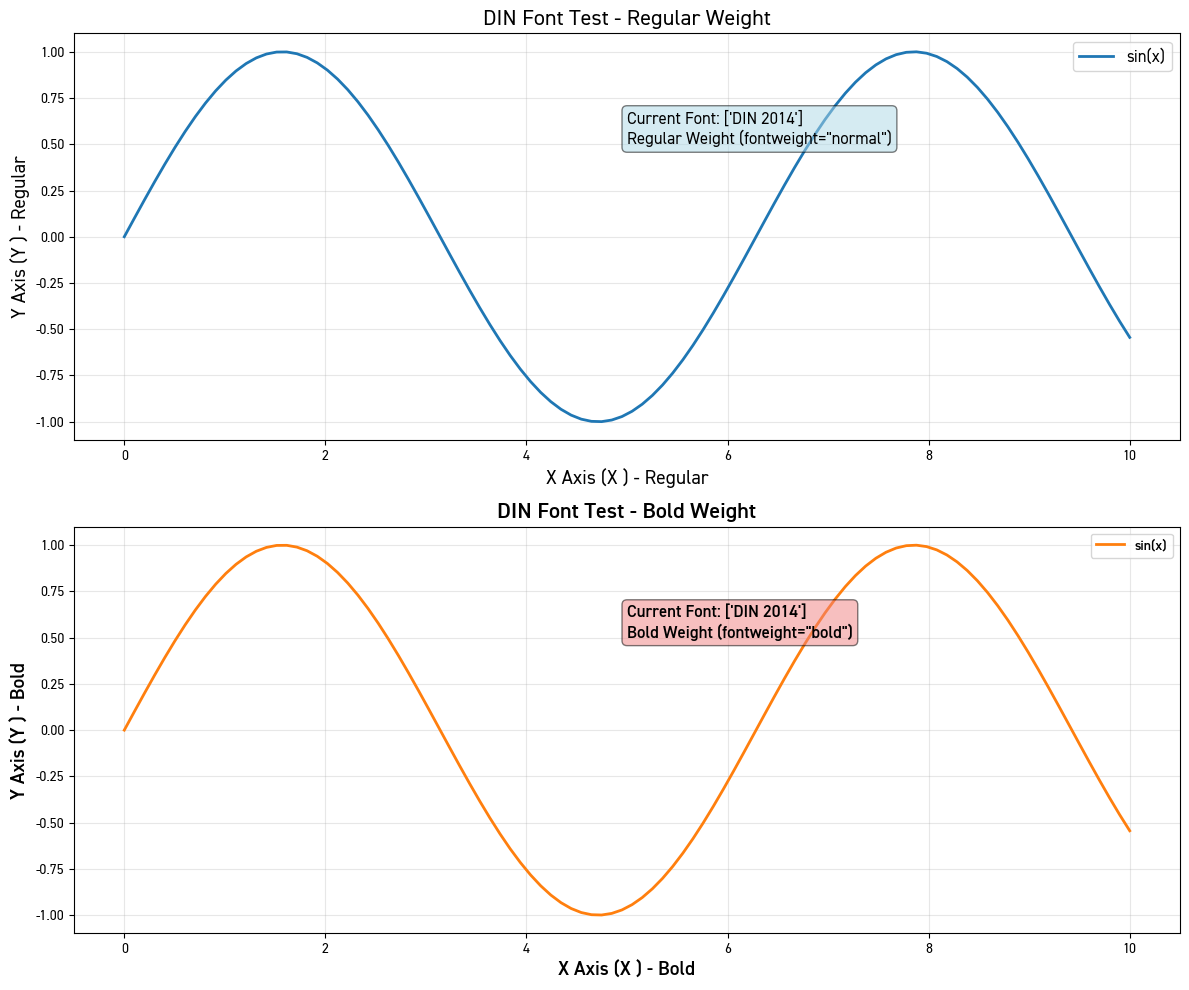


다양한 Font Weight 비교 테스트...
✓ Normal (normal): 테스트 완료
✓ Bold (bold): 테스트 완료
✓ Light (light): 테스트 완료
✓ Heavy (heavy): 테스트 완료
✓ Black (black): 테스트 완료


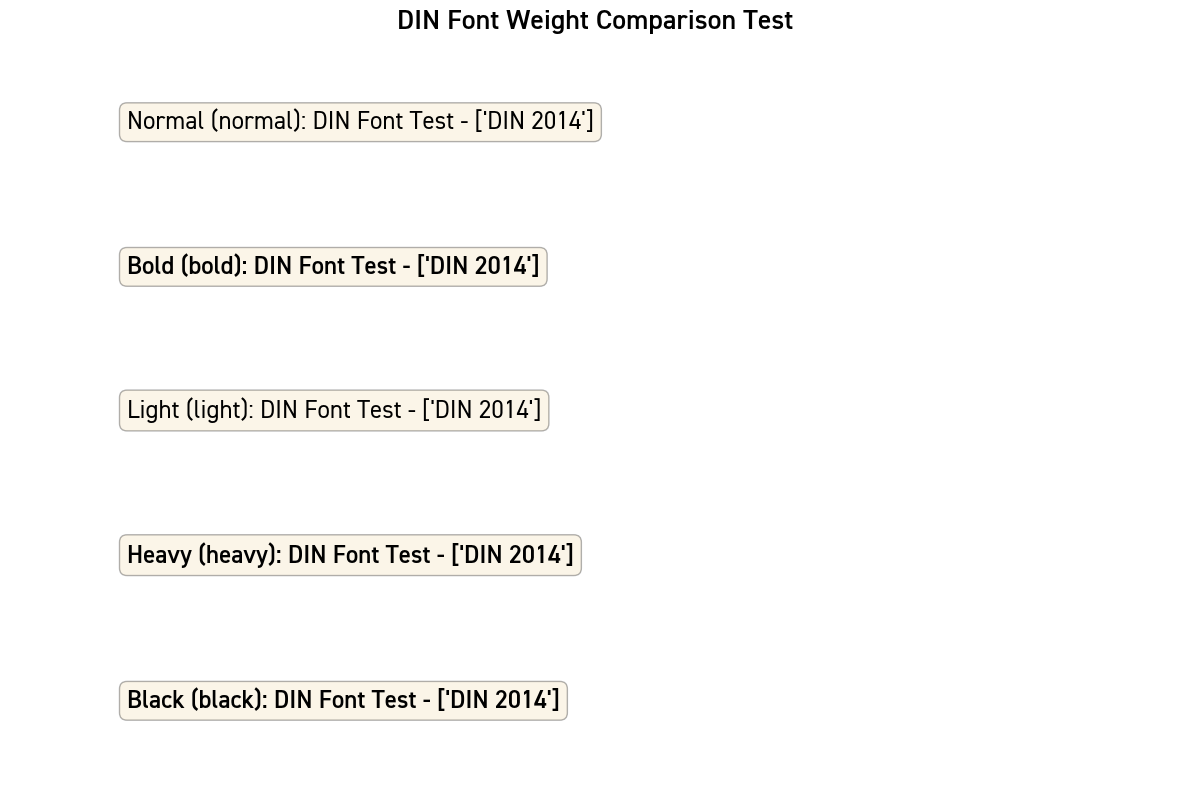


DIN 특정 Weight 직접 테스트...
✓ Condensed (DIN Condensed): 테스트 완료
✓ Regular (DIN 2014): 테스트 완료


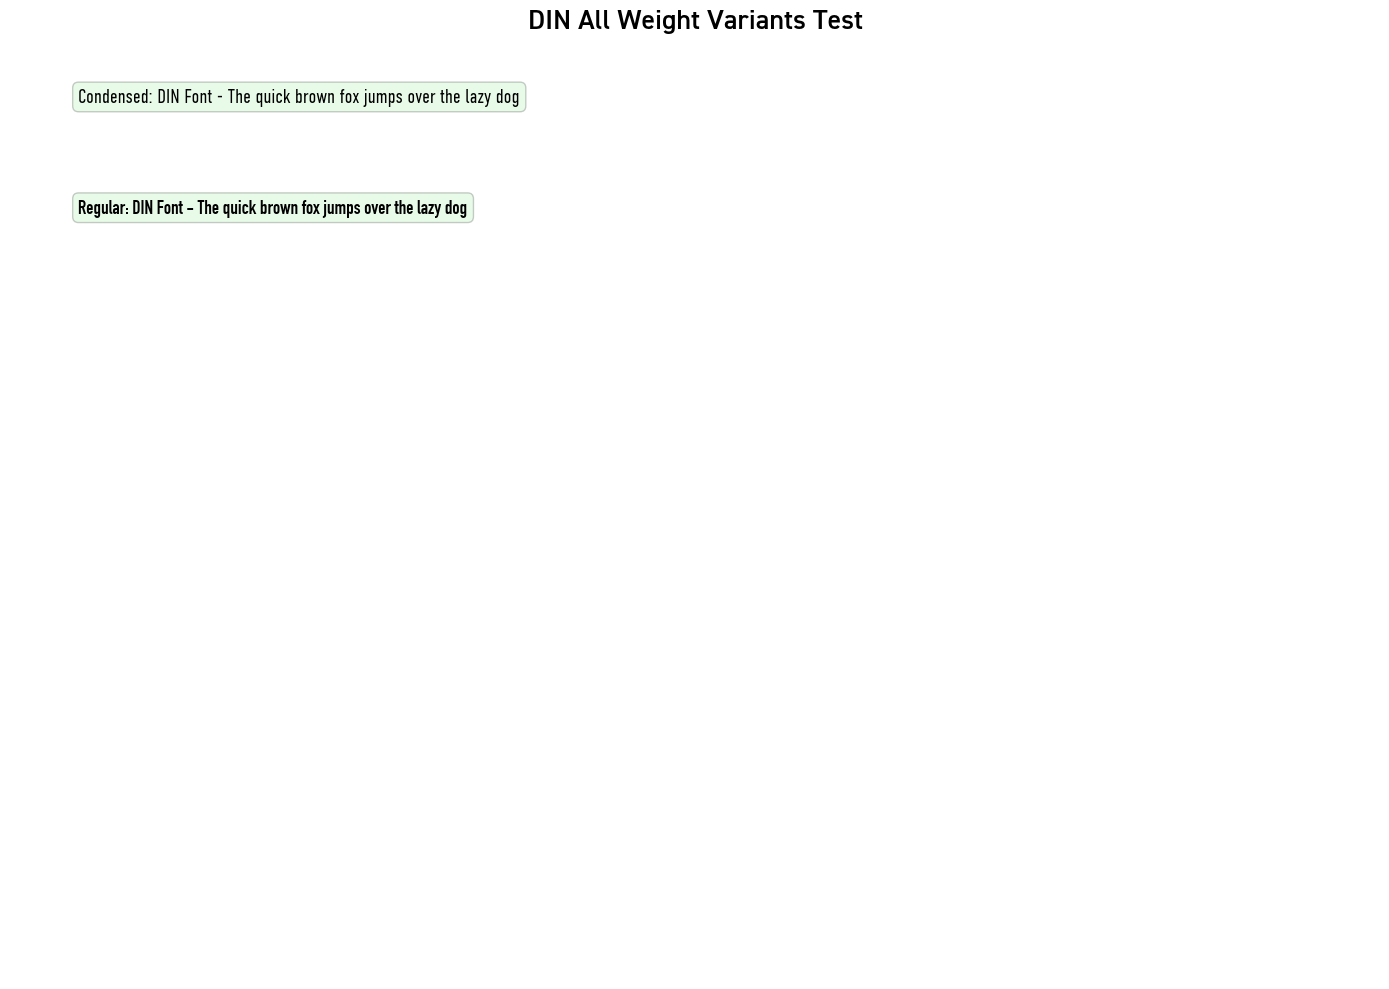


✓ 모든 테스트 플롯이 생성되었습니다.
  현재 사용 중인 폰트: ['DIN 2014']
  Bold 폰트 사용 가능: False


In [1]:
# DIN 폰트 설치 및 설정
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os
import numpy as np

# DIN 폰트 파일 경로
font_dir = '/root/25DFT/font'

# 폰트 디렉토리에서 모든 DIN 폰트 파일 찾기
font_files = []
if os.path.exists(font_dir):
    for file in os.listdir(font_dir):
        if file.lower().endswith(('.otf', '.ttf', '.ttc')) and 'din' in file.lower():
            font_path = os.path.join(font_dir, file)
            font_files.append(font_path)
            print(f"✓ 폰트 파일 발견: {file}")

print(f"\n총 {len(font_files)}개의 DIN 폰트 파일을 찾았습니다.\n")

# matplotlib에 폰트 직접 등록
registered_fonts = []
for font_path in font_files:
    try:
        # 폰트를 matplotlib에 직접 추가
        fm.fontManager.addfont(font_path)
        # 폰트 정보 가져오기
        font_prop = fm.FontProperties(fname=font_path)
        font_name = font_prop.get_name()
        registered_fonts.append((font_name, font_path))
        print(f"✓ 등록 성공: {font_name} ({os.path.basename(font_path)})")
    except Exception as e:
        print(f"✗ 등록 실패: {os.path.basename(font_path)} - {str(e)}")

# 등록된 폰트 확인
if registered_fonts:
    print(f"\n총 {len(registered_fonts)}개의 폰트가 등록되었습니다.")
    
    # matplotlib에서 인식된 DIN 폰트 확인
    all_fonts = sorted(set([f.name for f in fm.fontManager.ttflist]))
    din_fonts = [f for f in all_fonts if 'din' in f.lower()]
    
    print(f"\nmatplotlib에서 인식된 DIN 폰트:")
    for font in din_fonts:
        print(f"  - {font}")
    
    # DIN_2014 우선 사용, 없으면 DIN-Regular 사용
    din_font_props = [f for f in fm.fontManager.ttflist if 'DIN' in f.name or 'din' in f.name.lower()]
    if din_font_props:
        # DIN_2014 폰트 우선 찾기
        din_2014 = [f for f in din_font_props if '2014' in f.name and 'Bold' not in f.name and 'Italic' not in f.name and 'Demi' not in f.name and 'Narrow' not in f.name and 'Extra' not in f.name]
        if din_2014:
            din_font_name = din_2014[0].name
        else:
            # DIN_2014가 없으면 일반 DIN-Regular 사용
            din_regular = [f for f in din_font_props if 'Bold' not in f.name and 'Italic' not in f.name and 'Condensed' not in f.name and 'Exp' not in f.name and '2014' not in f.name]
            if din_regular:
                din_font_name = din_regular[0].name
            else:
                # Regular가 없으면 첫 번째 DIN 폰트 사용
                din_font_name = din_font_props[0].name
        
        plt.rcParams['font.family'] = din_font_name
        plt.rcParams['font.sans-serif'] = [din_font_name] + plt.rcParams['font.sans-serif']
        print(f"\n✓ DIN 폰트를 기본 폰트로 설정했습니다: {din_font_name}")
    else:
        # 등록은 되었지만 이름이 다른 경우
        din_font_name = registered_fonts[0][0]
        plt.rcParams['font.family'] = din_font_name
        plt.rcParams['font.sans-serif'] = [din_font_name] + plt.rcParams['font.sans-serif']
        print(f"\n✓ DIN 폰트를 기본 폰트로 설정했습니다: {din_font_name}")
else:
    # DIN이 없으면 대체 폰트 사용
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    if 'Arial' in available_fonts:
        plt.rcParams['font.family'] = 'Arial'
        print("\n⚠ DIN 폰트를 찾을 수 없습니다. Arial 폰트를 사용합니다.")
    elif 'Helvetica' in available_fonts:
        plt.rcParams['font.family'] = 'Helvetica'
        print("\n⚠ DIN 폰트를 찾을 수 없습니다. Helvetica 폰트를 사용합니다.")
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
        print("\n⚠ DIN 폰트를 찾을 수 없습니다. DejaVu Sans 폰트를 사용합니다.")

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호는 유지

# Bold 폰트 확인
print("\n" + "="*50)
print("DIN Bold 폰트 확인 중...")
print("="*50)

# Bold 폰트 파일이 있는지 확인
bold_font_files = [f for f in font_files if 'bold' in os.path.basename(f).lower() and 'italic' not in os.path.basename(f).lower()]
if bold_font_files:
    print(f"✓ Bold 폰트 파일 발견: {[os.path.basename(f) for f in bold_font_files]}")
    bold_available = True
else:
    print("⚠ 별도의 Bold 폰트 파일이 없습니다. (synthetic bold 사용 가능)")
    bold_available = False

# Bold 폰트 이름 확인 (DIN_2014 Bold 우선)
din_font_props = [f for f in fm.fontManager.ttflist if 'DIN' in f.name or 'din' in f.name.lower()]
# DIN_2014 Bold 우선 찾기
din_2014_bold = [f for f in din_font_props if '2014' in f.name and 'Bold' in f.name and 'Italic' not in f.name]
bold_font_names = [f.name for f in din_2014_bold] if din_2014_bold else [f.name for f in din_font_props if 'Bold' in f.name and 'Italic' not in f.name]
if bold_font_names:
    print(f"✓ Bold 폰트 이름: {bold_font_names}")
else:
    print("⚠ Bold 폰트 이름이 인식되지 않았습니다. (fontweight='bold'로 synthetic bold 시도)")
    
# 사용 가능한 모든 DIN weight 확인
print(f"\n사용 가능한 DIN 폰트 weight:")
weight_variants = {}
for font_prop in din_font_props:
    name = font_prop.name
    if 'Italic' not in name:
        if 'Bold' in name:
            weight_variants['Bold'] = name
        elif 'Condensed' in name:
            if 'Bold' in name:
                weight_variants['Condensed Bold'] = name
            else:
                weight_variants['Condensed'] = name
        elif 'Exp' in name:
            if 'Bold' in name:
                weight_variants['Exp Bold'] = name
            else:
                weight_variants['Exp'] = name
        else:
            weight_variants['Regular'] = name
            
for weight, name in sorted(weight_variants.items()):
    print(f"  - {weight}: {name}")

# 테스트 플롯 생성 - Regular vs Bold 비교
print("\n" + "="*50)
print("DIN 폰트 테스트 플롯 생성 중 (Regular & Bold 비교)...")
print("="*50)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 첫 번째 플롯: 기본 테스트
ax1 = axes[0]
x = np.linspace(0, 10, 100)
y = np.sin(x)

ax1.plot(x, y, linewidth=2, label='sin(x)')
ax1.set_xlabel('X Axis (X축) - Regular', fontsize=14)
ax1.set_ylabel('Y Axis (Y축) - Regular', fontsize=14)
ax1.set_title('DIN Font Test - Regular Weight', fontsize=16, fontweight='normal')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12)

current_font = plt.rcParams['font.family']
ax1.text(5, 0.5, f'Current Font: {current_font}\nRegular Weight (fontweight="normal")', 
        fontsize=12, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 두 번째 플롯: Bold 테스트
ax2 = axes[1]
ax2.plot(x, y, linewidth=2, label='sin(x)', color='C1')
ax2.set_xlabel('X Axis (X축) - Bold', fontsize=14, fontweight='bold')
ax2.set_ylabel('Y Axis (Y축) - Bold', fontsize=14, fontweight='bold')
ax2.set_title('DIN Font Test - Bold Weight', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12, prop={'weight': 'bold'})

# Bold 텍스트 추가
bold_text = f'Current Font: {current_font}\nBold Weight (fontweight="bold")'
ax2.text(5, 0.5, bold_text, 
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.tight_layout()
plt.show()

# 추가 테스트: 다양한 fontweight 비교
print("\n" + "="*50)
print("다양한 Font Weight 비교 테스트...")
print("="*50)

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

# 다양한 fontweight 테스트
weights = ['normal', 'bold', 'light', 'heavy', 'black']
weight_names = ['Normal', 'Bold', 'Light', 'Heavy', 'Black']
y_positions = np.linspace(0.9, 0.1, len(weights))

test_text = f"DIN Font Test - {current_font}"

for i, (weight, name) in enumerate(zip(weights, weight_names)):
    try:
        ax.text(0.1, y_positions[i], f'{name} ({weight}): {test_text}', 
               fontsize=18, fontweight=weight, 
               transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        print(f"✓ {name} ({weight}): 테스트 완료")
    except Exception as e:
        ax.text(0.1, y_positions[i], f'{name} ({weight}): [ERROR - {str(e)}]', 
               fontsize=18, transform=ax.transAxes,
               bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
        print(f"✗ {name} ({weight}): 오류 - {str(e)}")

ax.set_title('DIN Font Weight Comparison Test', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# DIN 특정 weight 직접 테스트
if 'weight_variants' in locals() and weight_variants:
    print("\n" + "="*50)
    print("DIN 특정 Weight 직접 테스트...")
    print("="*50)
    
    # weight 이름과 파일 경로 매핑 생성
    weight_to_file = {}
    for f_path in font_files:
        fname = os.path.basename(f_path).lower()
        if 'italic' not in fname:
            if 'bold' in fname:
                if 'condensed' in fname and 'Condensed Bold' not in weight_to_file:
                    weight_to_file['Condensed Bold'] = f_path
                elif 'exp' in fname and 'Exp Bold' not in weight_to_file:
                    weight_to_file['Exp Bold'] = f_path
                elif 'Bold' not in weight_to_file:
                    weight_to_file['Bold'] = f_path
            elif 'condensed' in fname and 'Condensed' not in weight_to_file:
                weight_to_file['Condensed'] = f_path
            elif 'exp' in fname and 'Exp' not in weight_to_file:
                weight_to_file['Exp'] = f_path
            elif 'Regular' not in weight_to_file:
                weight_to_file['Regular'] = f_path
    
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.axis('off')
    
    y_pos = 0.95
    test_text_base = "DIN Font - The quick brown fox jumps over the lazy dog"
    
    for weight_name, font_name in sorted(weight_variants.items()):
        try:
            # 파일 경로 찾기
            font_path = None
            if weight_name in weight_to_file:
                font_path = weight_to_file[weight_name]
            else:
                # registered_fonts에서 찾기
                for reg_name, reg_path in registered_fonts:
                    if font_name in reg_name:
                        font_path = reg_path
                        break
            
            if font_path and os.path.exists(font_path):
                font_prop = fm.FontProperties(fname=font_path)
                ax.text(0.05, y_pos, f'{weight_name}: {test_text_base}', 
                       fontsize=14, fontproperties=font_prop,
                       transform=ax.transAxes,
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.2))
                print(f"✓ {weight_name} ({font_name}): 테스트 완료")
            else:
                # 폰트 이름으로 직접 사용
                font_prop = fm.FontProperties(family=font_name)
                ax.text(0.05, y_pos, f'{weight_name}: {test_text_base}', 
                       fontsize=14, fontproperties=font_prop,
                       transform=ax.transAxes,
                       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.2))
                print(f"✓ {weight_name} ({font_name}): 테스트 완료 (이름으로)")
            y_pos -= 0.12
        except Exception as e:
            ax.text(0.05, y_pos, f'{weight_name}: [ERROR - {str(e)}]', 
                   fontsize=14, transform=ax.transAxes,
                   bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
            print(f"✗ {weight_name}: 오류 - {str(e)}")
            y_pos -= 0.12
    
    ax.set_title('DIN All Weight Variants Test', fontsize=20, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

print(f"\n✓ 모든 테스트 플롯이 생성되었습니다.")
print(f"  현재 사용 중인 폰트: {plt.rcParams['font.family']}")
if 'bold_available' in locals():
    print(f"  Bold 폰트 사용 가능: {bold_available}")

In [2]:
from pathlib import Path
import sys

# Import helper functions from this folder (no package/__init__.py required)
THIS_DIR = Path("/root/25DFT/QHFlow/src/md/test_script/test_analysis")
if str(THIS_DIR) not in sys.path:
    sys.path.insert(0, str(THIS_DIR))

import analysis as analysis_utils  # analysis.py in THIS_DIR

RESULTS_DIR = Path("/root/25DFT/QHFlow/src/md/test_script/dft_test_results_large_random_20260104_194839")

rows = analysis_utils.load_results_dir(RESULTS_DIR)
ok = [r for r in rows if r.get("status") == "ok"]
err = [r for r in rows if r.get("status") != "ok"]

print(f"Total json files: {len(rows)}")
print(f"OK: {len(ok)} | Error: {len(err)}")

def show_table(rs, cols, n=10):
    rs = list(rs)
    print("\t".join(cols))
    for r in rs[:n]:
        print("\t".join(str(r.get(c)) for c in cols))

print("\nSample OK rows:")
show_table(ok, ["file_stem", "atom_count", "min_dist_all_ang", "max_dist_all_ang", "energy_err_rks_vs_scflow_eV_per_atom", "H_force_mae_vec_eV_per_ang"], n=5)

if err:
    print("\nSample Error rows:")
    show_table(err, ["file_stem", "atom_count", "error"], n=5)


Total json files: 54
OK: 46 | Error: 8

Sample OK rows:
file_stem	atom_count	min_dist_all_ang	max_dist_all_ang	energy_err_rks_vs_scflow_eV_per_atom	H_force_mae_vec_eV_per_ang
177775400	152	0.973476379185957	17.44454138542659	-0.5135944352251068	1.5753686237766835
177775439	148	0.973571370149102	21.504561618226443	-0.020706367811284064	0.44921653645527254
177775635	153	0.9772693410084037	26.17575949073436	-0.015655606275186966	0.4041237013854288
177775643	155	0.9766911693682911	23.11260402464614	-0.010316056573590745	0.39977563376784264
177779160	156	0.9736529593679671	20.25026665089139	-0.012379612278145475	0.4892439559492049

Sample Error rows:
file_stem	atom_count	error
177700215	193	The following operation failed in the TorchScript interpreter.
Traceback of TorchScript (most recent call last):
  File "<eval_with_key>.120", line 355, in forward
    getitem_56 = reshape_2[(slice(None, None, None), slice(10496, 10752, None))]
    reshape_104 = getitem_56.reshape((-1, 256));  getitem_56

In [3]:
# Sort by minimum interatomic distance (global) and inspect extremes

cols = [
    "file_stem",
    "filename",
    "atom_count",
    "n_H",
    "min_dist_all_ang",
    "max_dist_all_ang",
    "min_dist_H_ang",
    "energy_err_rks_vs_scflow_eV_per_atom",
    "forces_mae_rks_vs_scflow_eV_per_ang",
    "H_force_mae_vec_eV_per_ang",
    "H_force_mae_comp_eV_per_ang",
]

def _sort_key(r):
    v = r.get("min_dist_all_ang")
    return (float("inf") if v is None else float(v))

ok_sorted = sorted(ok, key=_sort_key)

print("Smallest min_dist_all_ang:")
show_table(ok_sorted, cols, n=15)

print("\nLargest min_dist_all_ang:")
show_table(list(reversed(ok_sorted)), cols, n=15)


Smallest min_dist_all_ang:
file_stem	filename	atom_count	n_H	min_dist_all_ang	max_dist_all_ang	min_dist_H_ang	energy_err_rks_vs_scflow_eV_per_atom	forces_mae_rks_vs_scflow_eV_per_ang	H_force_mae_vec_eV_per_ang	H_force_mae_comp_eV_per_ang
177780558	177780558.xyz	148	58	0.0667885541765952	11.606606110405446	0.15659551288909906	-59.0195156073323	158.6970365270456	571.8407024647087	277.08123301284945
177820513	177820513.xyz	74	40	0.22004977381719804	12.468956715889185	0.22004977381719804	-18.106855170267483	39.694994195880064	233.14014598424848	121.3264214259868
177815370	177815370.xyz	88	44	0.22900880833278023	11.644182824211667	0.22900880833278023	-19.733668525748314	55.84584438267647	162.2768329574149	81.00725448206163
177820666	177820666.xyz	44	26	0.2579896546956873	7.034746139183417	0.5098629695173008	-24.33634710503818	67.16239905800818	332.68397485808106	171.5960352787093
177810731	177810731.xyz	114	48	0.3003610284241282	18.804484832566406	0.3003610284241282	-27.751765841283614	70.1

In [4]:
# Overall stats: energy error + H-only force MAE

# Energy error can be signed; usually for "error" people also want |error|.

def print_stats(name, values):
    stats = analysis_utils.summarize_values(values)
    print(name)
    print(stats)
    print()

print_stats(
    "energy_err_rks_vs_scflow_eV_per_atom (signed)",
    [r.get("energy_err_rks_vs_scflow_eV_per_atom") for r in ok],
)
print_stats(
    "abs_energy_err_rks_vs_scflow_eV_per_atom",
    [abs(r.get("energy_err_rks_vs_scflow_eV_per_atom")) for r in ok if r.get("energy_err_rks_vs_scflow_eV_per_atom") is not None],
)

print_stats(
    "forces_mae_rks_vs_scflow_eV_per_ang (overall)",
    [r.get("forces_mae_rks_vs_scflow_eV_per_ang") for r in ok],
)
print_stats(
    "H_force_mae_vec_eV_per_ang (mean ||ΔF|| on H)",
    [r.get("H_force_mae_vec_eV_per_ang") for r in ok],
)
print_stats(
    "H_force_mae_comp_eV_per_ang (mean |ΔF_component| on H)",
    [r.get("H_force_mae_comp_eV_per_ang") for r in ok],
)

print_stats(
    "max_dist_all_ang (structure diameter)",
    [r.get("max_dist_all_ang") for r in ok],
)


energy_err_rks_vs_scflow_eV_per_atom (signed)
{'count': 46.0, 'mean': -5.004486088159915, 'std': 11.367715770846901, 'min': -59.0195156073323, 'p25': -0.8505061456828242, 'p50': -0.0074090017762054525, 'p75': -0.0027980754034395735, 'p95': -0.001666976702324227, 'max': -0.0011462781887227418}

abs_energy_err_rks_vs_scflow_eV_per_atom
{'count': 46.0, 'mean': 5.004486088159915, 'std': 11.367715770846901, 'min': 0.0011462781887227418, 'p25': 0.0027980754034395735, 'p50': 0.0074090017762054525, 'p75': 0.8505061456828242, 'p95': 24.35456683849521, 'max': 59.0195156073323}

forces_mae_rks_vs_scflow_eV_per_ang (overall)
{'count': 46.0, 'mean': 11.98271673286751, 'std': 29.22258434164221, 'min': 0.013450375306465402, 'p25': 0.020215110285603376, 'p50': 0.034686846893268564, 'p75': 0.9474904126521073, 'p95': 64.33326038917525, 'max': 158.6970365270456}

H_force_mae_vec_eV_per_ang (mean ||ΔF|| on H)
{'count': 46.0, 'mean': 47.11501105305531, 'std': 116.27675202822515, 'min': 0.06010985342656177,

In [5]:
# Stats by distance bins (using min_dist_all_ang)
# Default bins: [0.0, 0.8), then 0.2Å steps up to 3.0Å, then [3.0, inf)

bin_edges = [0.0] + [round(x, 1) for x in [0.8 + 0.2 * i for i in range(int((3.0 - 0.8) / 0.2) + 1)]] + [float("inf")]

ok_with_bin = []
for r in ok:
    rr = dict(r)
    rr["dist_bin"] = analysis_utils.assign_bin(rr.get("min_dist_all_ang"), bin_edges)
    e = rr.get("energy_err_rks_vs_scflow_eV_per_atom")
    rr["abs_energy_err_rks_vs_scflow_eV_per_atom"] = (abs(e) if e is not None else None)
    ok_with_bin.append(rr)

metrics = ["abs_energy_err_rks_vs_scflow_eV_per_atom", "H_force_mae_vec_eV_per_ang"]
stats_rows = analysis_utils.group_stats(ok_with_bin, "dist_bin", metrics)

print("dist_bin\tn\tabs_energy_err_mean(eV/atom)\tabs_energy_err_p50\tH_F_mae_vec_mean(eV/Å)\tH_F_mae_vec_p50")
for r in stats_rows:
    print(
        f"{r.get('dist_bin')}\t{r.get('n')}\t"
        f"{r.get('abs_energy_err_rks_vs_scflow_eV_per_atom')}\t{r.get('abs_energy_err_rks_vs_scflow_eV_per_atom_p50')}\t"
        f"{r.get('H_force_mae_vec_eV_per_ang')}\t{r.get('H_force_mae_vec_eV_per_ang_p50')}"
    )


dist_bin	n	abs_energy_err_mean(eV/atom)	abs_energy_err_p50	H_F_mae_vec_mean(eV/Å)	H_F_mae_vec_p50
[0.0, 0.8)	10	22.53114262529398	20.73236467209069	215.4346102135345	178.54696279390922
[0.8, 1.0)	24	0.05666817458628918	0.005384447130000485	0.2958761098896569	0.14202364260234687
[1.0, 1.2)	12	0.29457480102878064	0.007304287759071142	0.4869483056539778	0.21013070912794568


In [6]:
# Stats by atom size bins (using atom_count)

atom_bins = [0.0] + [float(x) for x in range(50, 301, 25)] + [float("inf")]

ok_with_bin = []
for r in ok:
    rr = dict(r)
    rr["atom_bin"] = analysis_utils.assign_bin(rr.get("atom_count"), atom_bins)
    e = rr.get("energy_err_rks_vs_scflow_eV_per_atom")
    rr["abs_energy_err_rks_vs_scflow_eV_per_atom"] = (abs(e) if e is not None else None)
    ok_with_bin.append(rr)

metrics = ["abs_energy_err_rks_vs_scflow_eV_per_atom", "H_force_mae_vec_eV_per_ang"]
stats_rows = analysis_utils.group_stats(ok_with_bin, "atom_bin", metrics)

print("atom_bin\tn\tabs_energy_err_mean(eV/atom)\tabs_energy_err_p50\tH_F_mae_vec_mean(eV/Å)\tH_F_mae_vec_p50")
for r in stats_rows:
    print(
        f"{r.get('atom_bin')}\t{r.get('n')}\t"
        f"{r.get('abs_energy_err_rks_vs_scflow_eV_per_atom')}\t{r.get('abs_energy_err_rks_vs_scflow_eV_per_atom_p50')}\t"
        f"{r.get('H_force_mae_vec_eV_per_ang')}\t{r.get('H_force_mae_vec_eV_per_ang_p50')}"
    )


atom_bin	n	abs_energy_err_mean(eV/atom)	abs_energy_err_p50	H_F_mae_vec_mean(eV/Å)	H_F_mae_vec_p50
[0.0, 50.0)	7	5.2380801364586045	0.002598928319962902	55.35938010755309	0.16762390469088123
[100.0, 125.0)	8	9.9472760685923	2.856607443123476	88.87594003291116	12.452121859374556
[125.0, 150.0)	4	18.04336589897669	6.566620810381584	165.9020899405922	45.65922038060242
[150.0, 175.0)	4	0.1379864275880075	0.014017609276666222	0.71712797871979	0.4466838286673168
[50.0, 75.0)	11	1.649254950218645	0.0026604175979931216	21.289352871001963	0.1012950191117878
[75.0, 100.0)	12	1.924531399395299	0.013914178911761837	14.008964513842828	0.20188297603336397


Plot points: 36 | skipped_missing: 0 | skipped_min_dist<0.8: 10


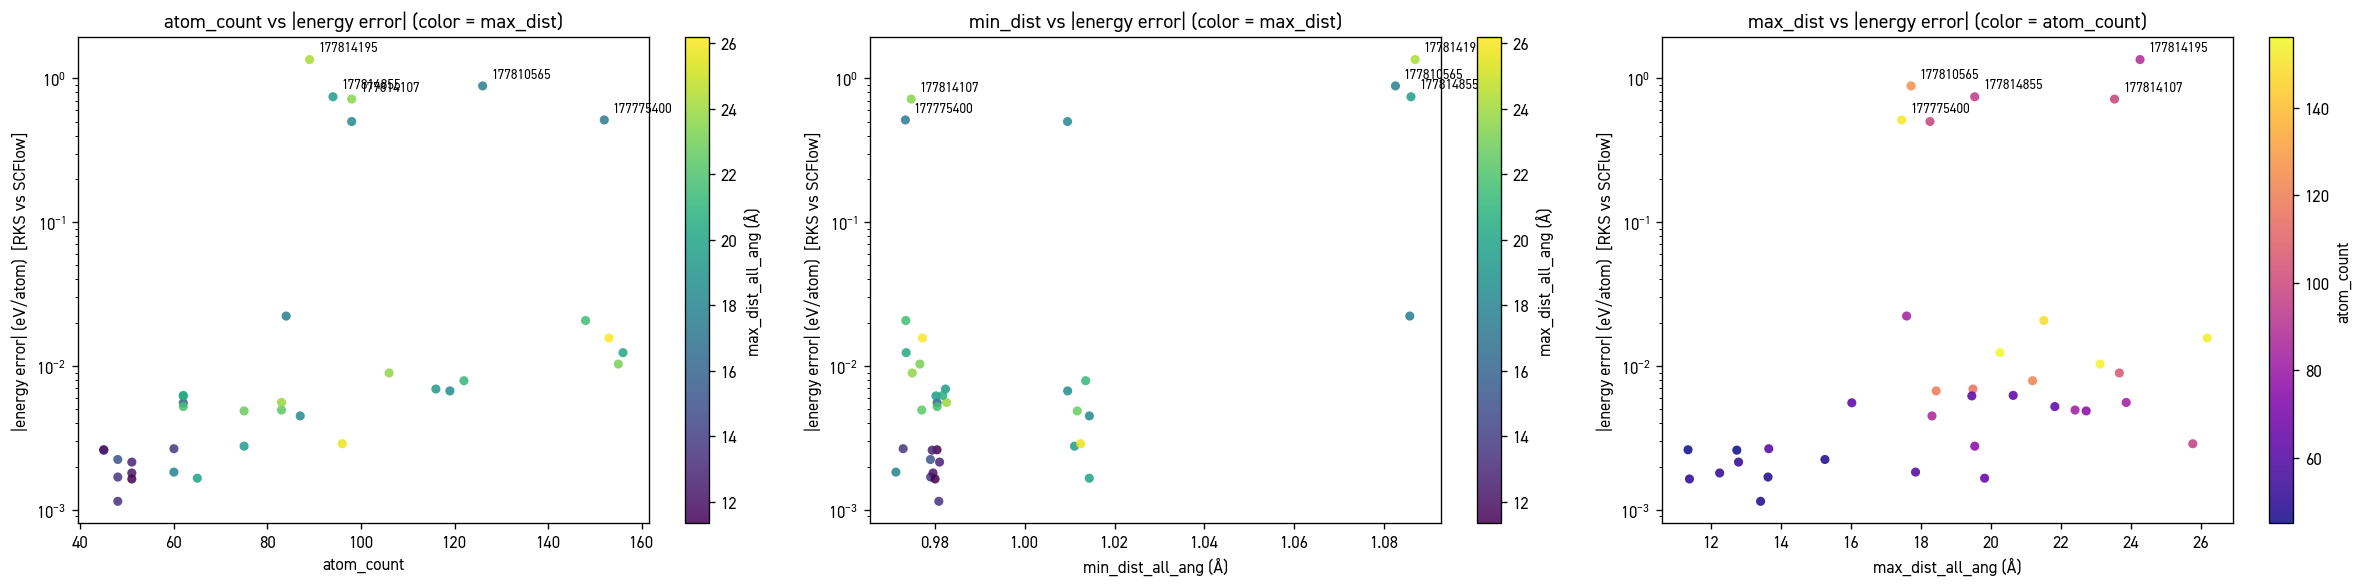

In [7]:
# Scatter plots: atom size / min dist / max dist vs |energy error|
# (Run this notebook with conda env/kernel: pyscf-gpu)

import matplotlib.pyplot as plt

# --- options ---
APPLY_MIN_DIST_FILTER = True
MIN_DIST_CUTOFF = 0.8  # Å

# Build plotting arrays from ok rows
xs_atom = []
xs_mind = []
xs_maxd = []
ys_absE = []
cs_maxd = []
cs_atom = []
labels = []

skipped_missing = 0
skipped_too_close = 0

for r in ok:
    atom_count = r.get("atom_count")
    min_d = r.get("min_dist_all_ang")
    max_d = r.get("max_dist_all_ang")
    e = r.get("energy_err_rks_vs_scflow_eV_per_atom")
    if atom_count is None or min_d is None or max_d is None or e is None:
        skipped_missing += 1
        continue

    # Filter out too-small min distances (likely unphysical close contacts)
    if APPLY_MIN_DIST_FILTER and float(min_d) < MIN_DIST_CUTOFF:
        skipped_too_close += 1
        continue

    y = abs(float(e))
    # avoid log(0)
    if y <= 0:
        y = 1e-12

    xs_atom.append(float(atom_count))
    xs_mind.append(float(min_d))
    xs_maxd.append(float(max_d))
    ys_absE.append(y)

    cs_maxd.append(float(max_d))
    cs_atom.append(float(atom_count))
    labels.append(str(r.get("file_stem")))

if APPLY_MIN_DIST_FILTER:
    print(f"Plot points: {len(xs_atom)} | skipped_missing: {skipped_missing} | skipped_min_dist<{MIN_DIST_CUTOFF}: {skipped_too_close}")
else:
    print(f"Plot points: {len(xs_atom)} | skipped_missing: {skipped_missing} | min_dist filter: OFF")

fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=120)

# (1) atom_count vs |energy error|, colored by max_dist
sc0 = axes[0].scatter(xs_atom, ys_absE, c=cs_maxd, cmap="viridis", s=30, alpha=0.85, edgecolors="none")
axes[0].set_xlabel("atom_count")
axes[0].set_ylabel("|energy error| (eV/atom)  [RKS vs SCFlow]")
axes[0].set_yscale("log")
axes[0].set_title("atom_count vs |energy error| (color = max_dist)")
cb0 = fig.colorbar(sc0, ax=axes[0])
cb0.set_label("max_dist_all_ang (Å)")

# (2) min_dist vs |energy error|, colored by max_dist
sc2 = axes[1].scatter(xs_mind, ys_absE, c=cs_maxd, cmap="viridis", s=30, alpha=0.85, edgecolors="none")
axes[1].set_xlabel("min_dist_all_ang (Å)")
axes[1].set_ylabel("|energy error| (eV/atom)  [RKS vs SCFlow]")
axes[1].set_yscale("log")
axes[1].set_title("min_dist vs |energy error| (color = max_dist)")
cb2 = fig.colorbar(sc2, ax=axes[1])
cb2.set_label("max_dist_all_ang (Å)")

# (3) max_dist vs |energy error|, colored by atom_count
sc1 = axes[2].scatter(xs_maxd, ys_absE, c=cs_atom, cmap="plasma", s=30, alpha=0.85, edgecolors="none")
axes[2].set_xlabel("max_dist_all_ang (Å)")
axes[2].set_ylabel("|energy error| (eV/atom)  [RKS vs SCFlow]")
axes[2].set_yscale("log")
axes[2].set_title("max_dist vs |energy error| (color = atom_count)")
cb1 = fig.colorbar(sc1, ax=axes[2])
cb1.set_label("atom_count")

# Annotate top-K largest errors (helps test your hypothesis quickly)
K = 5
idx_sorted = sorted(range(len(ys_absE)), key=lambda i: ys_absE[i], reverse=True)[:K]
for i in idx_sorted:
    axes[0].annotate(labels[i], (xs_atom[i], ys_absE[i]), textcoords="offset points", xytext=(5, 5), fontsize=8)
    axes[1].annotate(labels[i], (xs_mind[i], ys_absE[i]), textcoords="offset points", xytext=(5, 5), fontsize=8)
    axes[2].annotate(labels[i], (xs_maxd[i], ys_absE[i]), textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.show()


Plot points: 36 | skipped_missing: 0 | skipped_min_dist<0.8: 10


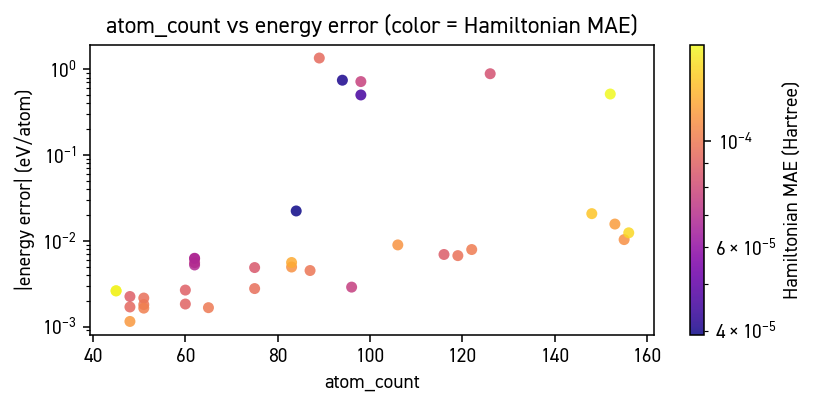

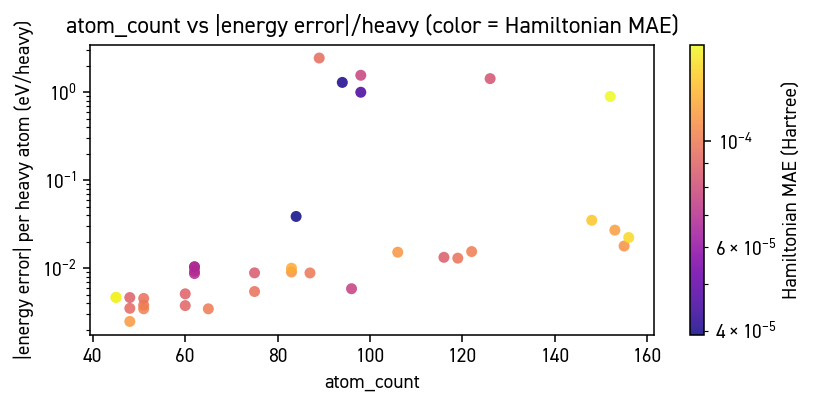

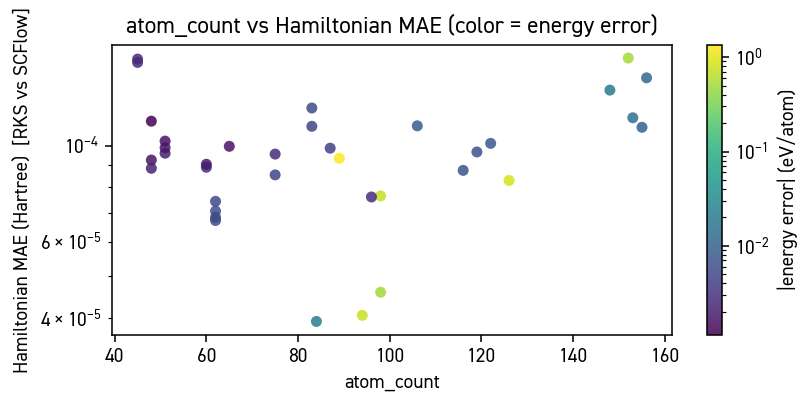

In [8]:
# Final plots: atom_count vs energy error, atom_count vs H error (+ energy error per heavy atom)
# Uses DIN font set in the top font cell (plt.rcParams)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# --- options ---
APPLY_MIN_DIST_FILTER = True
MIN_DIST_CUTOFF = 0.8  # Å
USE_ABS_ENERGY_ERROR = True
PLOT_ENERGY_PER_HEAVY = True  # adds (|ΔE_total| / n_heavy)

# Refresh data here so we don't accidentally use stale `ok` rows
# (e.g., after changing analysis.py to add `hamiltonian_mae_rks_vs_scflow_hartree`).
from pathlib import Path
import sys

THIS_DIR = Path("/root/25DFT/QHFlow/src/md/test_script/test_analysis")
if str(THIS_DIR) not in sys.path:
    sys.path.insert(0, str(THIS_DIR))

import analysis as analysis_utils

RESULTS_DIR = Path("/root/25DFT/QHFlow/src/md/test_script/dft_test_results_large_random_20260104_194839")
rows = analysis_utils.load_results_dir(RESULTS_DIR)
ok = [r for r in rows if r.get("status") == "ok"]


def collect_points(ok_rows):
    xs = []
    ys_E = []
    ys_E_per_heavy = []
    ys_H = []
    labels = []

    skipped_missing = 0
    skipped_too_close = 0

    for r in ok_rows:
        atom_count = r.get("atom_count")
        min_d = r.get("min_dist_all_ang")
        e_pa = r.get("energy_err_rks_vs_scflow_eV_per_atom")
        e_tot = r.get("energy_err_rks_vs_scflow_eV")
        # H := Hamiltonian MAE (Hartree)
        h = r.get("hamiltonian_mae_rks_vs_scflow_hartree")
        n_heavy = r.get("n_heavy")

        # required fields
        if atom_count is None or min_d is None or e_pa is None or h is None:
            skipped_missing += 1
            continue

        # min_dist is used only as a filter here (not plotted)
        # IMPORTANT: NaN comparisons are always False, so explicitly drop non-finite min_d
        try:
            min_d_f = float(min_d)
        except Exception:
            skipped_missing += 1
            continue

        if not np.isfinite(min_d_f):
            skipped_missing += 1
            continue

        if APPLY_MIN_DIST_FILTER and min_d_f < MIN_DIST_CUTOFF:
            skipped_too_close += 1
            continue

        # energy error (per atom)
        ee = float(e_pa)
        if USE_ABS_ENERGY_ERROR:
            ee = abs(ee)

        # total energy error (eV) -> per heavy atom
        if e_tot is not None:
            ee_tot = float(e_tot)
        else:
            ee_tot = float(e_pa) * float(atom_count)

        ee_hvy = np.nan
        if n_heavy is not None and float(n_heavy) > 0:
            ee_hvy = (abs(ee_tot) / float(n_heavy)) if USE_ABS_ENERGY_ERROR else (ee_tot / float(n_heavy))

        xs.append(float(atom_count))
        ys_E.append(float(ee))
        ys_E_per_heavy.append(float(ee_hvy))
        ys_H.append(float(h))
        labels.append(str(r.get("file_stem")))

    return (
        np.asarray(xs),
        np.asarray(ys_E),
        np.asarray(ys_E_per_heavy, dtype=float),
        np.asarray(ys_H),
        labels,
        skipped_missing,
        skipped_too_close,
    )


x, yE, yE_hvy, yH, labels, skipped_missing, skipped_too_close = collect_points(ok)

if APPLY_MIN_DIST_FILTER:
    print(
        f"Plot points: {len(x)} | skipped_missing: {skipped_missing} | skipped_min_dist<{MIN_DIST_CUTOFF}: {skipped_too_close}"
    )
else:
    print(f"Plot points: {len(x)} | skipped_missing: {skipped_missing} | min_dist filter: OFF")

# --- (1) atom_count vs energy error (color = Hamiltonian MAE) ---
fig1, ax1 = plt.subplots(figsize=(6, 3), dpi=140)

# Color by Hamiltonian MAE (Hartree)
vmin_H = float(np.min(yH[yH > 0])) if np.any(yH > 0) else 1e-12
vmax_H = float(np.max(yH)) if yH.size else 1.0

sc1 = ax1.scatter(
    x,
    yE,
    c=yH,
    cmap="plasma",
    norm=LogNorm(vmin=vmin_H, vmax=vmax_H),
    s=32,
    alpha=0.85,
    edgecolors="none",
)
ax1.set_xlabel("atom_count")
ax1.set_ylabel(("|energy error|" if USE_ABS_ENERGY_ERROR else "energy error") + " (eV/atom)")
ax1.set_yscale("log")
ax1.set_title("atom_count vs energy error (color = Hamiltonian MAE)")
cb1 = fig1.colorbar(sc1, ax=ax1)
cb1.set_label("Hamiltonian MAE (Hartree)")

plt.tight_layout()
plt.show()

# --- (1b) atom_count vs energy error per heavy atom (color = Hamiltonian MAE) ---
if PLOT_ENERGY_PER_HEAVY:
    mask = np.isfinite(yE_hvy) & (yE_hvy > 0)
    xh = x[mask]
    yEh = yE_hvy[mask]
    yHh = yH[mask]

    fig1b, ax1b = plt.subplots(figsize=(6, 3), dpi=140)

    sc1b = ax1b.scatter(
        xh,
        yEh,
        c=yHh,
        cmap="plasma",
        norm=LogNorm(vmin=vmin_H, vmax=vmax_H),
        s=32,
        alpha=0.85,
        edgecolors="none",
    )
    ax1b.set_xlabel("atom_count")
    ax1b.set_ylabel("|energy error| per heavy atom (eV/heavy)")
    ax1b.set_yscale("log")
    ax1b.set_title("atom_count vs |energy error|/heavy (color = Hamiltonian MAE)")
    cb1b = fig1b.colorbar(sc1b, ax=ax1b)
    cb1b.set_label("Hamiltonian MAE (Hartree)")

    plt.tight_layout()
    plt.show()

# --- (2) atom_count vs Hamiltonian MAE (color = energy error) ---
fig2, ax2 = plt.subplots(figsize=(6, 3), dpi=140)

# Color by energy error (eV/atom)
vmin_E = float(np.min(yE[yE > 0])) if np.any(yE > 0) else 1e-12
vmax_E = float(np.max(yE)) if yE.size else 1.0

sc2 = ax2.scatter(
    x,
    yH,
    c=yE,
    cmap="viridis",
    norm=LogNorm(vmin=vmin_E, vmax=vmax_E),
    s=32,
    alpha=0.85,
    edgecolors="none",
)
ax2.set_xlabel("atom_count")
ax2.set_ylabel("Hamiltonian MAE (Hartree)  [RKS vs SCFlow]")
ax2.set_yscale("log")
ax2.set_title("atom_count vs Hamiltonian MAE (color = energy error)")
cb2 = fig2.colorbar(sc2, ax=ax2)
cb2.set_label(("|energy error|" if USE_ABS_ENERGY_ERROR else "energy error") + " (eV/atom)")

plt.tight_layout()
plt.show()


In [9]:
# Numeric stats for the final plots (filter ON vs OFF)
# + atom_count bins: 40~80 / 80~120 / 120~160 / all

import numpy as np


def _pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2:
        return float("nan")
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt((x * x).sum() * (y * y).sum())
    return float((x * y).sum() / denom) if denom != 0 else float("nan")


def _summ(name, arr):
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        print(name, "EMPTY")
        return
    qs = np.quantile(arr, [0, 0.25, 0.5, 0.75, 0.95, 1.0])
    print(name)
    print("  n:", int(arr.size))
    print("  mean:", float(arr.mean()))
    print("  std:", float(arr.std(ddof=1)) if arr.size > 1 else 0.0)
    print("  min/p25/p50/p75/p95/max:", [float(q) for q in qs])


def collect_points_with_filter(ok_rows, apply_filter: bool, min_cut: float, use_abs_E: bool):
    xs = []
    yE = []
    yH = []
    maxd = []
    mind = []

    for r in ok_rows:
        atom_count = r.get("atom_count")
        min_d = r.get("min_dist_all_ang")
        max_d = r.get("max_dist_all_ang")
        e = r.get("energy_err_rks_vs_scflow_eV_per_atom")
        h = r.get("hamiltonian_mae_rks_vs_scflow_hartree")
        if atom_count is None or min_d is None or max_d is None or e is None or h is None:
            continue
        try:
            min_d_f = float(min_d)
        except Exception:
            continue
        if not np.isfinite(min_d_f):
            continue
        if apply_filter and min_d_f < min_cut:
            continue
        ee = float(e)
        if use_abs_E:
            ee = abs(ee)
        xs.append(float(atom_count))
        yE.append(float(ee))
        yH.append(float(h))
        maxd.append(float(max_d))
        mind.append(float(min_d))

    return np.asarray(xs), np.asarray(yE), np.asarray(yH), np.asarray(mind), np.asarray(maxd)


ATOM_BINS = [
    (40, 80, "40~80"),
    (80, 120, "80~120"),
    (120, 160, "120~160"),
    (None, None, "all"),
]


def _mask_atom_bin(x, lo, hi):
    if lo is None and hi is None:
        return np.ones_like(x, dtype=bool)
    if hi is None:
        return x >= lo
    return (x >= lo) & (x < hi)


for apply_filter in [False, True]:
    x, yE, yH, mind, maxd = collect_points_with_filter(
        ok,
        apply_filter=apply_filter,
        min_cut=0.8,
        use_abs_E=True,
    )

    print("\n" + "=" * 100)
    print("Filter:", ("ON (min_dist>=0.8Å)" if apply_filter else "OFF (all)"))
    print("=" * 100)

    for lo, hi, name in ATOM_BINS:
        m = _mask_atom_bin(x, lo, hi)
        xb = x[m]
        yEb = yE[m]
        yHb = yH[m]
        mindb = mind[m]
        maxdb = maxd[m]

        print("\n" + "-" * 70)
        if lo is None:
            print(f"atom_count bin: {name} (all)")
        else:
            print(f"atom_count bin: {name}  (x in [{lo}, {hi}))")
        print("-" * 70)

        _summ("|E| (eV/atom)", yEb)
        _summ("Hamiltonian MAE (Hartree)", yHb)
        _summ("atom_count", xb)
        _summ("min_dist_all_ang (Å)", mindb)
        _summ("max_dist_all_ang (Å)", maxdb)

        print("\nCorrelations (Pearson):")
        print("  corr(atom_count, |E|):", _pearson(xb, yEb) if len(xb) >= 2 else float("nan"))
        print("  corr(atom_count, Hamiltonian MAE):", _pearson(xb, yHb) if len(xb) >= 2 else float("nan"))
        print("  corr(max_dist, |E|):", _pearson(maxdb, yEb) if len(xb) >= 2 else float("nan"))
        print("  corr(min_dist, |E|):", _pearson(mindb, yEb) if len(xb) >= 2 else float("nan"))
        print("  corr(min_dist, Hamiltonian MAE):", _pearson(mindb, yHb) if len(xb) >= 2 else float("nan"))



Filter: OFF (all)

----------------------------------------------------------------------
atom_count bin: 40~80  (x in [40, 80))
----------------------------------------------------------------------
|E| (eV/atom)
  n: 20
  mean: 2.7408002836271494
  std: 6.964787452430395
  min/p25/p50/p75/p95/max: [0.0011462781887227418, 0.001822936920084698, 0.002637671412958298, 0.005709306772792667, 18.41832976700602, 24.33634710503818]
Hamiltonian MAE (Hartree)
  n: 20
  mean: 0.0007257285249016173
  std: 0.0018198932871673877
  min/p25/p50/p75/p95/max: [6.710753704901974e-05, 8.78231095698217e-05, 9.57659177985775e-05, 0.00012424718321062198, 0.0029513704975605497, 0.007758745599755213]
atom_count
  n: 20
  mean: 56.85
  std: 10.23551608243005
  min/p25/p50/p75/p95/max: [44.0, 48.0, 55.5, 62.0, 75.0, 75.0]
min_dist_all_ang (Å)
  n: 20
  mean: 0.8914008330378902
  std: 0.23900493676470472
  min/p25/p50/p75/p95/max: [0.22004977381719804, 0.9775272137747776, 0.980179792288201, 0.9809587118144071, 

In [10]:
# Correlation analysis: which factors explain |energy error| / H error the most?
# - Pearson: linear correlation (sensitive to outliers)
# - Spearman: rank correlation (more robust to outliers / nonlinear monotonic trends)

import numpy as np

# --- options ---
APPLY_MIN_DIST_FILTER = True
MIN_DIST_CUTOFF = 0.8  # Å
OUTLIER_TRIM_Q = 0.95  # remove top (1-q) fraction by |E| in the trimmed analysis


def _as_float(x):
    try:
        v = float(x)
    except Exception:
        return None
    if np.isnan(v) or np.isinf(v):
        return None
    return v


def _pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 2:
        return float("nan")
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt((x * x).sum() * (y * y).sum())
    return float((x * y).sum() / denom) if denom != 0 else float("nan")


def _rankdata(a):
    a = np.asarray(a)
    order = np.argsort(a)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(a), dtype=float)
    return ranks


def _spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 2:
        return float("nan")
    return _pearson(_rankdata(x), _rankdata(y))


def build_rows(ok_rows):
    rows2 = []
    skipped_missing = 0
    skipped_too_close = 0

    for r in ok_rows:
        atom_count = _as_float(r.get("atom_count"))
        n_H = _as_float(r.get("n_H"))
        min_d = _as_float(r.get("min_dist_all_ang"))
        min_dH = _as_float(r.get("min_dist_H_ang"))
        max_d = _as_float(r.get("max_dist_all_ang"))
        e = _as_float(r.get("energy_err_rks_vs_scflow_eV_per_atom"))
        h = _as_float(r.get("hamiltonian_mae_rks_vs_scflow_hartree"))

        if atom_count is None or min_d is None or max_d is None or e is None or h is None:
            skipped_missing += 1
            continue
        # IMPORTANT: NaN comparisons are always False, so explicitly drop non-finite min_d
        if not np.isfinite(min_d):
            skipped_missing += 1
            continue
        if APPLY_MIN_DIST_FILTER and min_d < MIN_DIST_CUTOFF:
            skipped_too_close += 1
            continue

        absE = abs(e)
        n_heavy = None
        heavy_frac = None
        if n_H is not None:
            n_heavy = atom_count - n_H
            heavy_frac = (n_heavy / atom_count) if atom_count > 0 else None

        # energy error per heavy atom (using total ΔE / n_heavy)
        e_tot = _as_float(r.get("energy_err_rks_vs_scflow_eV"))
        if e_tot is None:
            e_tot = e * atom_count
        absE_per_heavy = None
        if n_heavy is not None and n_heavy > 0:
            absE_per_heavy = abs(e_tot) / n_heavy

        rows2.append(
            {
                "atom_count": atom_count,
                "n_H": n_H,
                "n_heavy": n_heavy,
                "H_frac": (n_H / atom_count) if (n_H is not None and atom_count > 0) else None,
                "heavy_frac": heavy_frac,
                "min_dist": min_d,
                "min_dist_H": min_dH,
                "max_dist": max_d,
                "diam_over_min": (max_d / min_d) if min_d > 0 else None,
                "absE": absE,
                "absE_per_heavy": absE_per_heavy,
                "H_err": h,
                "stem": str(r.get("file_stem")),
            }
        )

    return rows2, skipped_missing, skipped_too_close


rows2, skipped_missing, skipped_too_close = build_rows(ok)
print(f"Rows for correlation: {len(rows2)} | skipped_missing: {skipped_missing} | skipped_close: {skipped_too_close}")

keys_x = [
    "atom_count",
    "n_H",
    "n_heavy",
    "H_frac",
    "heavy_frac",
    "min_dist",
    "min_dist_H",
    "max_dist",
    "diam_over_min",
]


def corr_table(rows2, y_key, trim=False):
    rs = list(rows2)
    if trim:
        # trim by absE (top tail)
        absE = np.array([r["absE"] for r in rs], dtype=float)
        thr = np.quantile(absE, OUTLIER_TRIM_Q)
        rs = [r for r in rs if r["absE"] <= thr]

    out = []
    y = np.array([r[y_key] for r in rs], dtype=float)

    for k in keys_x:
        xx = []
        yy = []
        for r, yi in zip(rs, y):
            xi = r.get(k)
            if xi is None:
                continue
            xx.append(float(xi))
            yy.append(float(yi))
        if len(xx) < 3:
            continue
        xx = np.asarray(xx)
        yy = np.asarray(yy)
        out.append(
            {
                "x": k,
                "n": int(len(xx)),
                "spearman": _spearman(xx, yy),
                "pearson": _pearson(xx, yy),
            }
        )

    out.sort(key=lambda d: (abs(d["spearman"]), abs(d["pearson"])), reverse=True)
    return out


for y_key in ["absE", "absE_per_heavy", "H_err"]:
    print("\n" + "=" * 90)
    print(f"Target: {y_key}  |  Filter: {'ON' if APPLY_MIN_DIST_FILTER else 'OFF'} (cut={MIN_DIST_CUTOFF})")
    print("=" * 90)

    base = corr_table(rows2, y_key, trim=False)
    trimmed = corr_table(rows2, y_key, trim=True)

    print("\nTop correlations (ALL points):")
    for d in base[:6]:
        print(f"  {d['x']:<12} n={d['n']:<3} spearman={d['spearman']:+.3f}  pearson={d['pearson']:+.3f}")

    print(f"\nTop correlations (TRIMMED by |E| <= q{OUTLIER_TRIM_Q:.2f}):")
    for d in trimmed[:6]:
        print(f"  {d['x']:<12} n={d['n']:<3} spearman={d['spearman']:+.3f}  pearson={d['pearson']:+.3f}")

# Show which structures are the biggest |E| outliers under current filter
absE = np.array([r["absE"] for r in rows2], dtype=float)
idx = np.argsort(absE)[::-1][:10]
print("\nTop |E| outliers (after current min_dist filter setting):")
for i in idx:
    r = rows2[int(i)]
    print(
        f"  stem={r['stem']} |E|={r['absE']:.4g} eV/atom  min_dist={r['min_dist']:.3f}Å  max_dist={r['max_dist']:.2f}Å  atom_count={int(r['atom_count'])}"
    )


Rows for correlation: 36 | skipped_missing: 0 | skipped_close: 10

Target: absE  |  Filter: ON (cut=0.8)

Top correlations (ALL points):
  n_heavy      n=36  spearman=+0.849  pearson=+0.243
  atom_count   n=36  spearman=+0.798  pearson=+0.234
  n_H          n=36  spearman=+0.641  pearson=+0.210
  H_frac       n=36  spearman=-0.573  pearson=-0.156
  heavy_frac   n=36  spearman=+0.571  pearson=+0.156
  max_dist     n=36  spearman=+0.515  pearson=+0.207

Top correlations (TRIMMED by |E| <= q0.95):
  n_heavy      n=34  spearman=+0.859  pearson=+0.209
  atom_count   n=34  spearman=+0.807  pearson=+0.241
  n_H          n=34  spearman=+0.665  pearson=+0.275
  H_frac       n=34  spearman=-0.551  pearson=+0.025
  heavy_frac   n=34  spearman=+0.550  pearson=-0.025
  max_dist     n=34  spearman=+0.529  pearson=+0.126

Target: absE_per_heavy  |  Filter: ON (cut=0.8)

Top correlations (ALL points):
  n_heavy      n=36  spearman=+0.843  pearson=+0.223
  atom_count   n=36  spearman=+0.798  pearson=+0